In [33]:


# 1. IMPORT REQUIRED LIBRARIES


import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [34]:
# 2. LOAD DATASET

import pandas as pd

df = pd.read_csv("twitter_dataset.csv")

print(df.head())

   Tweet_ID        Username  \
0         1         julie81   
1         2   richardhester   
2         3  williamsjoseph   
3         4     danielsmary   
4         5      carlwarren   

                                                Text  Retweets  Likes  \
0  Party least receive say or single. Prevent pre...         2     25   
1  Hotel still Congress may member staff. Media d...        35     29   
2  Nice be her debate industry that year. Film wh...        51     25   
3  Laugh explain situation career occur serious. ...        37     18   
4  Involve sense former often approach government...        27     80   

             Timestamp  
0  2023-01-30 11:00:51  
1  2023-01-02 22:45:58  
2  2023-01-18 11:25:19  
3  2023-04-10 22:06:29  
4  2023-01-24 07:12:21  


In [35]:
# 4. GENERATE SENTIMENT USING VADER

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)

    if score['compound'] >= 0.05:
        return "positive"
    elif score['compound'] <= -0.05:
        return "negative"
    else:
        return "neutral"

# Apply on your Text column
df["sentiment"] = df["Text"].apply(get_sentiment)

print(df[["Text", "sentiment"]].head())

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                Text sentiment
0  Party least receive say or single. Prevent pre...  positive
1  Hotel still Congress may member staff. Media d...  positive
2  Nice be her debate industry that year. Film wh...  positive
3  Laugh explain situation career occur serious. ...  positive
4  Involve sense former often approach government...  positive


In [36]:
# 3. EXPLORE THE DATASET

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment value counts:")
print(df["sentiment"].value_counts())

First 5 rows of dataset:
   Tweet_ID        Username  \
0         1         julie81   
1         2   richardhester   
2         3  williamsjoseph   
3         4     danielsmary   
4         5      carlwarren   

                                                Text  Retweets  Likes  \
0  Party least receive say or single. Prevent pre...         2     25   
1  Hotel still Congress may member staff. Media d...        35     29   
2  Nice be her debate industry that year. Film wh...        51     25   
3  Laugh explain situation career occur serious. ...        37     18   
4  Involve sense former often approach government...        27     80   

             Timestamp sentiment  
0  2023-01-30 11:00:51  positive  
1  2023-01-02 22:45:58  positive  
2  2023-01-18 11:25:19  positive  
3  2023-04-10 22:06:29  positive  
4  2023-01-24 07:12:21  positive  

Dataset shape:
(10000, 7)

Column names:
Index(['Tweet_ID', 'Username', 'Text', 'Retweets', 'Likes', 'Timestamp',
       'sentiment'],
   

In [ ]:

# 3. DATA CLEANING

# Convert Timestamp column to datetime format

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Remove duplicate tweets using Tweet_ID

df = df.drop_duplicates(subset="Tweet_ID")

# Remove rows where tweet text is missing

df = df[df["Text"].notna()]
df = df[df["Text"].str.strip() != ""]

# Fill missing engagement values with 0

df["Likes"] = df["Likes"].fillna(0)
df["Retweets"] = df["Retweets"].fillna(0)

# Create a Total Engagement metric

df["Total_Engagement"] = df["Likes"] + df["Retweets"]

In [ ]:

# 4. SENTIMENT ANALYSIS



def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply sentiment function to tweet text
df["Sentiment_Score"] = df["Text"].apply(get_sentiment)


def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Label"] = df["Sentiment_Score"].apply(sentiment_label)

In [39]:

# 5. TIME-BASED ENGAGEMENT ANALYSIS (Idea 2)


# Extract time-related features from Timestamp
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.day_name()
df["Month"] = df["Timestamp"].dt.month

# Average engagement by hour of posting
engagement_by_hour = df.groupby("Hour")["Total_Engagement"].mean()

# Average engagement by day of the week
engagement_by_day = df.groupby("DayOfWeek")["Total_Engagement"].mean()

In [40]:

# 6. BASIC ENGAGEMENT ANALYSIS


# Average engagement by sentiment category
engagement_by_sentiment = df.groupby("Sentiment_Label")["Total_Engagement"].mean()

# Identify top 10 tweets by total engagement
top_tweets = df.sort_values("Total_Engagement", ascending=False).head(10)

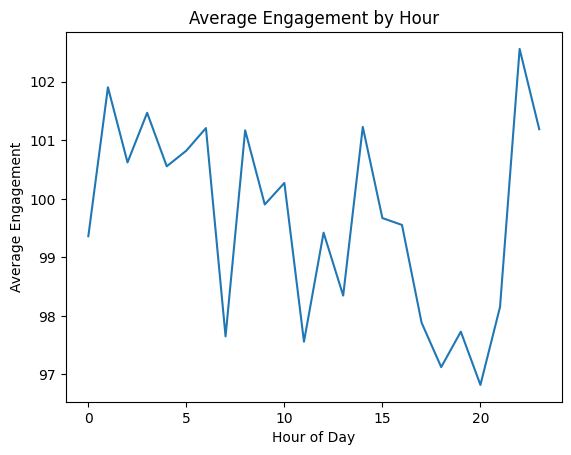

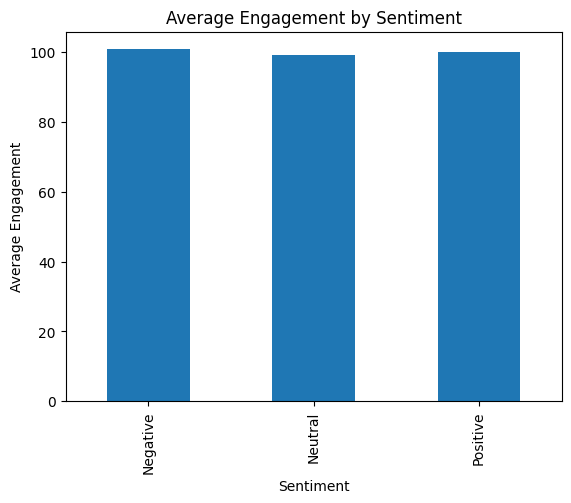

In [41]:

# 7. VISUALIZATION


# Plot engagement by hour
plt.figure()
engagement_by_hour.plot(kind="line")
plt.title("Average Engagement by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Engagement")
plt.show()

# Plot engagement by sentiment
plt.figure()
engagement_by_sentiment.plot(kind="bar")
plt.title("Average Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Engagement")
plt.show()

In [ ]:

# 8. SAVE CLEANED DATA



df.to_csv("cleaned_social_media_data.csv", index=False)

In [43]:

# 9. PRINT KEY INSIGHTS


print("=== Sentiment Distribution ===")
print(df["Sentiment_Label"].value_counts())

print("\n=== Engagement by Sentiment ===")
print(engagement_by_sentiment)

print("\n=== Top 10 Tweets by Engagement ===")
print(top_tweets[["Tweet_ID", "Total_Engagement", "Sentiment_Label"]])

=== Sentiment Distribution ===
Sentiment_Label
Neutral     4858
Positive    4631
Negative     511
Name: count, dtype: int64

=== Engagement by Sentiment ===
Sentiment_Label
Negative    100.831703
Neutral      99.253808
Positive     99.936299
Name: Total_Engagement, dtype: float64

=== Top 10 Tweets by Engagement ===
      Tweet_ID  Total_Engagement Sentiment_Label
2818      2819               200         Neutral
3552      3553               199        Positive
3574      3575               198         Neutral
3190      3191               197        Positive
4010      4011               197         Neutral
9091      9092               197         Neutral
3783      3784               197        Negative
6995      6996               197        Positive
5145      5146               196        Positive
11          12               196         Neutral


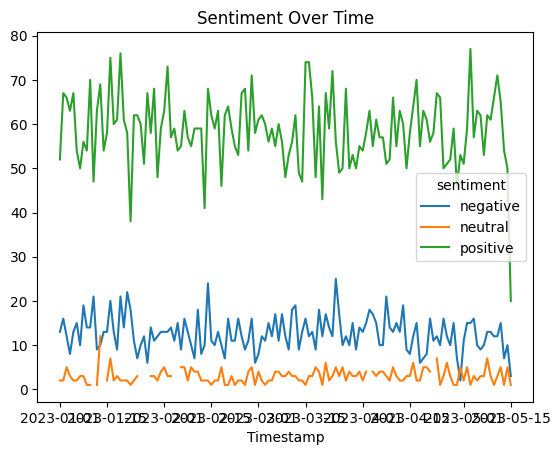

In [44]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.groupby(df["Timestamp"].dt.date)["sentiment"].value_counts().unstack().plot()
plt.title("Sentiment Over Time")
plt.show()

In [45]:
from collections import Counter

positive_text = " ".join(df[df["sentiment"]=="positive"]["Text"])
negative_text = " ".join(df[df["sentiment"]=="negative"]["Text"])

pos_words = Counter(positive_text.split()).most_common(10)
neg_words = Counter(negative_text.split()).most_common(10)

print("Top Positive Words:", pos_words)
print("Top Negative Words:", neg_words)

Top Positive Words: [('successful', 234), ('Democrat', 228), ('best', 224), ('good', 222), ('maybe', 222), ('yourself', 221), ('rich', 221), ('American', 220), ('I', 220), ('top', 220)]
Top Negative Words: [('war', 103), ('threat', 100), ('crime', 94), ('attack', 93), ('bad', 92), ('suffer', 91), ('wrong', 88), ('worry', 85), ('poor', 81), ('drop', 77)]


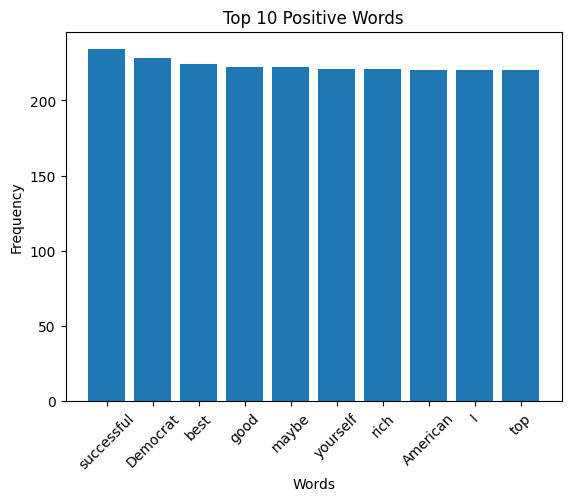

In [ ]:
words = [w[0] for w in pos_words]
counts = [w[1] for w in pos_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Positive Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

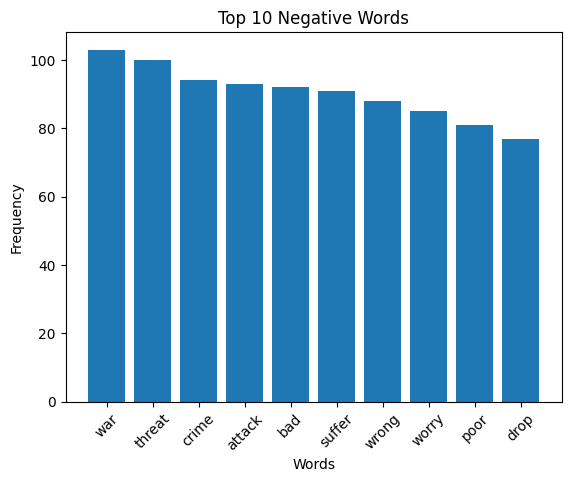

In [ ]:
words = [w[0] for w in neg_words]
counts = [w[1] for w in neg_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Negative Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv("final_sentiment_data.csv", index=False)

In [14]:
print(df["Text"].head(20))

0     Party least receive say or single. Prevent pre...
1     Hotel still Congress may member staff. Media d...
2     Nice be her debate industry that year. Film wh...
3     Laugh explain situation career occur serious. ...
4     Involve sense former often approach government...
5     Cell without report weight. Could father chang...
6     Receive difference their. Responsibility build...
7     Five sort guy why politics than. Somebody pret...
8     Reveal table state view manager she. Fly yeah ...
9     List allow family rather continue. Agency mess...
10    Image simply article list event imagine want r...
11    You hold central. Seem miss look very. None hi...
12    Paper but then field audience. Read pick sudde...
13    Population way sport late strategy. Pay positi...
14    Red thousand low answer walk. Few film follow ...
15    Describe school building play believe. Finish ...
16    Some activity one.\nWestern color agreement vi...
17    Color since door without crime increase th

In [15]:
print(df["sentiment"].value_counts())

sentiment
positive    7390
neutral     1351
negative    1259
Name: count, dtype: int64


In [50]:
# Compare VADER and TextBlob labels
comparison_table = pd.crosstab(df["sentiment"], df["Sentiment_Label"])

print("Comparison between VADER and TextBlob:")
print(comparison_table)

Comparison between VADER and TextBlob:
Sentiment_Label  Negative  Neutral  Positive
sentiment                                   
negative              213     1102       396
neutral                39      243       106
positive              259     3513      4129


In [18]:
print(df.columns)

Index(['Tweet_ID', 'Username', 'Text', 'Retweets', 'Likes', 'Timestamp',
       'sentiment', 'debug', 'clean_text'],
      dtype='object')


In [19]:
from textblob import TextBlob

def textblob_label(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0.1:
        return "positive"
    elif polarity < -0.1:
        return "negative"
    else:
        return "neutral"

df["Sentiment_Label"] = df["clean_text"].apply(textblob_label)

In [20]:
comparison_table = pd.crosstab(df["sentiment"], df["Sentiment_Label"])

print("Comparison between VADER and TextBlob:")
print(comparison_table)

Comparison between VADER and TextBlob:
Sentiment_Label  negative  neutral  positive
sentiment                                   
negative              178      815       266
neutral               114      843       394
positive              219     3200      3971


In [22]:
df["compound_score"] = df["debug"].apply(lambda x: x["compound"])

In [26]:
def sentiment_strength(score):
    if abs(score) >= 0.7:
        return "strong"
    elif abs(score) >= 0.3:
        return "moderate"
    else:
        return "weak"

df["sentiment_strength"] = df["compound_score"].apply(sentiment_strength)

print(df[["Text", "sentiment", "compound_score", "sentiment_strength"]].head())

                                                Text sentiment  \
0  Party least receive say or single. Prevent pre...  positive   
1  Hotel still Congress may member staff. Media d...  positive   
2  Nice be her debate industry that year. Film wh...  positive   
3  Laugh explain situation career occur serious. ...  positive   
4  Involve sense former often approach government...  positive   

   compound_score sentiment_strength  
0          0.8885             strong  
1          0.2960               weak  
2          0.8481             strong  
3          0.6249           moderate  
4          0.6705           moderate  


In [27]:
from collections import Counter

positive_text = " ".join(df[df["sentiment"] == "positive"]["clean_text"])
negative_text = " ".join(df[df["sentiment"] == "negative"]["clean_text"])

positive_words = Counter(positive_text.split()).most_common(10)
negative_words = Counter(negative_text.split()).most_common(10)

print("Top 10 Positive Words:")
print(positive_words)

print("\nTop 10 Negative Words:")
print(negative_words)

Top 10 Positive Words:
[('success', 369), ('successful', 348), ('accept', 340), ('enjoy', 338), ('best', 337), ('growth', 335), ('easy', 333), ('good', 332), ('save', 328), ('friend', 328)]

Top 10 Negative Words:
[('crime', 133), ('war', 129), ('fear', 128), ('threat', 127), ('suffer', 119), ('bad', 111), ('wrong', 106), ('worry', 100), ('attack', 100), ('lose', 97)]


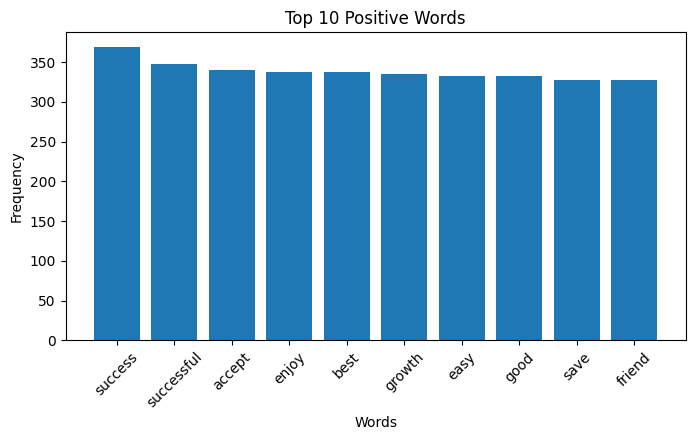

In [46]:
pos_words = [word[0] for word in positive_words]
pos_counts = [word[1] for word in positive_words]

plt.figure(figsize=(8, 4))
plt.bar(pos_words, pos_counts)
plt.title("Top 10 Positive Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

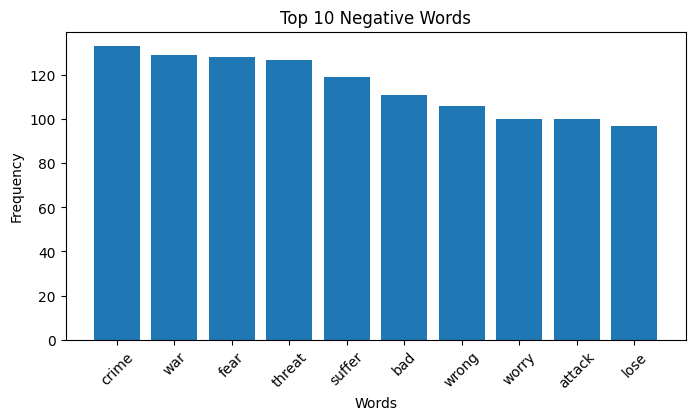

In [47]:
neg_words = [word[0] for word in negative_words]
neg_counts = [word[1] for word in negative_words]

plt.figure(figsize=(8, 4))
plt.bar(neg_words, neg_counts)
plt.title("Top 10 Negative Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

Average Engagement by Sentiment:
sentiment
negative    101.303331
neutral      98.110825
positive     99.368181
Name: Total_Engagement, dtype: float64


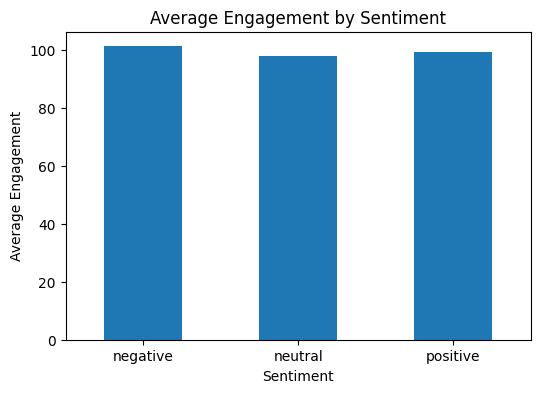

In [48]:
df["Total_Engagement"] = df["Likes"] + df["Retweets"]

engagement_by_sentiment = df.groupby("sentiment")["Total_Engagement"].mean()

print("Average Engagement by Sentiment:")
print(engagement_by_sentiment)

plt.figure(figsize=(6, 4))
engagement_by_sentiment.plot(kind="bar")
plt.title("Average Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Engagement")
plt.xticks(rotation=0)
plt.show()

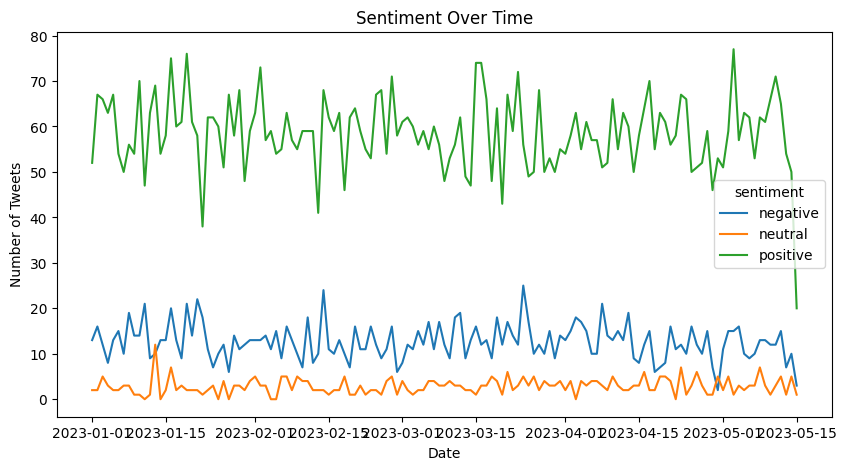

In [49]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

daily_sentiment = df.groupby(df["Timestamp"].dt.date)["sentiment"].value_counts().unstack().fillna(0)

plt.figure(figsize=(10, 5))
daily_sentiment.plot(ax=plt.gca())
plt.title("Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.show()